## Task 5

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

class MyClass(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.features(x)

model = MyClass()

loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=1,gamma=0.95)

def train(model, dataloader, criterion, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss/len(dataloader)

def test(model,dataloader,criterion):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0,0 

    with torch.no_grad():
        for X,y in dataloader:
            pred=model(X)
            test_loss+=criterion(pred, y)
            correct+=(pred.argmax(1)==y).type(torch.float).sum().item()
    test_loss/=num_batches
    correct/=size
    print(f"Test Error: \n Accuracy: {(100*correct):.1f}%, Avg loss: {test_loss:.4f} \n") 
    return 100*correct/size

for epoch in range(10):
    print(f"Epoch {epoch+1}\n ----------------------------")
    train(model,train_dataloader,loss_func,optimizer)
    test(model,test_dataloader,loss_func)

    scheduler.step()

print("Done!")               


Epoch 1
 ----------------------------
Test Error: 
 Accuracy: 96.9%, Avg loss: 0.1033 

Epoch 2
 ----------------------------
Test Error: 
 Accuracy: 97.6%, Avg loss: 0.0763 

Epoch 3
 ----------------------------
Test Error: 
 Accuracy: 97.8%, Avg loss: 0.0728 

Epoch 4
 ----------------------------
Test Error: 
 Accuracy: 98.0%, Avg loss: 0.0689 

Epoch 5
 ----------------------------
Test Error: 
 Accuracy: 97.8%, Avg loss: 0.0829 

Epoch 6
 ----------------------------
Test Error: 
 Accuracy: 97.6%, Avg loss: 0.0980 

Epoch 7
 ----------------------------
Test Error: 
 Accuracy: 98.0%, Avg loss: 0.0855 

Epoch 8
 ----------------------------
Test Error: 
 Accuracy: 97.5%, Avg loss: 0.1111 

Epoch 9
 ----------------------------
Test Error: 
 Accuracy: 97.4%, Avg loss: 0.1189 

Epoch 10
 ----------------------------
Test Error: 
 Accuracy: 98.1%, Avg loss: 0.0983 

Done!


## Task 6


In [17]:
torch.save(model.state_dict(), "model.pt")

In [16]:
model = MyClass()
model.load_state_dict(torch.load("model.pt"))
model.eval()

MyClass(
  (features): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=10, bias=True)
  )
)

Epoch 1
 ----------------------------
Test Error: 
 Accuracy: 98.1%, Avg loss: 0.0925 

Epoch 2
 ----------------------------
Test Error: 
 Accuracy: 98.1%, Avg loss: 0.1018 

Epoch 3
 ----------------------------
Test Error: 
 Accuracy: 98.2%, Avg loss: 0.1050 

Epoch 4
 ----------------------------
Test Error: 
 Accuracy: 98.1%, Avg loss: 0.1149 

Epoch 5
 ----------------------------
Test Error: 
 Accuracy: 98.3%, Avg loss: 0.1020 

Epoch 6
 ----------------------------
Test Error: 
 Accuracy: 98.2%, Avg loss: 0.1054 

Epoch 7
 ----------------------------
Test Error: 
 Accuracy: 98.5%, Avg loss: 0.0950 

Epoch 8
 ----------------------------
Test Error: 
 Accuracy: 98.4%, Avg loss: 0.1032 

Epoch 9
 ----------------------------
Test Error: 
 Accuracy: 98.4%, Avg loss: 0.1092 

Epoch 10
 ----------------------------
Test Error: 
 Accuracy: 98.3%, Avg loss: 0.1164 



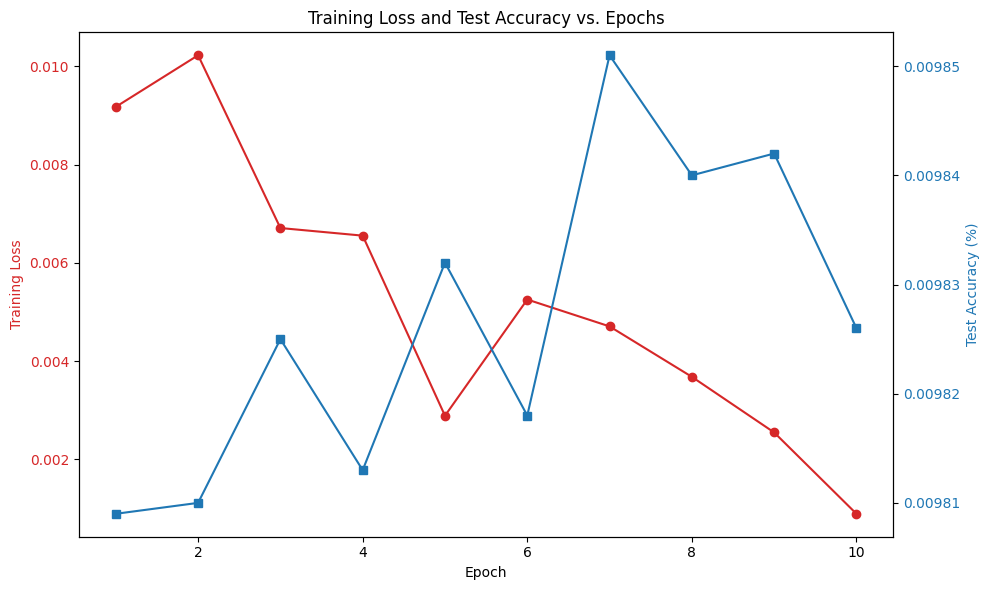

In [15]:
import matplotlib.pyplot as plt

train_losses = []
test_accuracies = []

for epoch in range(10):
    print(f"Epoch {epoch+1}\n ----------------------------")
    
    avg_loss = train(model, train_dataloader, loss_func, optimizer)
    train_losses.append(avg_loss)
    
    accuracy = test(model, test_dataloader, loss_func)
    test_accuracies.append(accuracy)
    
    scheduler.step()

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color)
ax1.plot(range(1, 11), train_losses, color=color, marker='o', label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx() 
color = 'tab:blue'
ax2.set_ylabel('Test Accuracy (%)', color=color)
ax2.plot(range(1, 11), test_accuracies, color=color, marker='s', label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Loss and Test Accuracy vs. Epochs')
fig.tight_layout()
plt.show()